<a href="https://colab.research.google.com/github/psalazarec/TestPython/blob/main/Actividad1_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 1: red MLP

### **Construye una red Perceptrón Multicapa para clasificar imágenes de ropa en escala de grises, del dataset Fashion MNIST.**

El dataset FashionMNIST esta formado por imágenes del mismo tamaño y canales que las del dataset MNIST original de números escritos a mano, por lo que puede usarse gran parte del código del ejercicio resuelto MNIST_MLP como ayuda.

Los criterios de evaluación pueden ser consultados en la rúbrica de la actividad. Sólo una propuesta de red y ejecución de entrenamiento debe ser entregada. Por supuesto, os animo a que probéis distintas configuraciones de red y entrenamiento, pero la entrega debe ser sólo con vuestro mejor resultado.

Si te surgen problemas, aconsejo partir de la red del ejercicio resuelto y tocar poco a poco parámetros, para ver que efecto tienen. Si te atascas, no dudes en publicar tus dudas en el tablon para que otros alumnos o el profesor te pueda ayudar.

Añado el codigo de inicializacion de Pytorch, de carga de la base de datos FashionMNIST, y de pintar unas imagenes para comprobar que se ha cargado correctamente.

**La entrega de la actividad será el archivo del cuaderno de Jupyter (archivo .ipynb). Puede descargarse desde Archivo > Descargar > Descargar .ipynb**

In [1]:
!pip install torchview

In [2]:
# importamos la libreria pytorch
import torch
from torch import nn
from torch import optim #las funciones de optimizacion (gradient descent)
from torch.optim.lr_scheduler import StepLR #learning rate decay
import torch.nn.functional as F #convencion
from torchvision import datasets, transforms

# matplotlib para pintar graficas
import matplotlib.pyplot as plt
%matplotlib inline

from torchview import draw_graph
import graphviz

In [3]:
# usamos la GPU si esta disponible
if torch.cuda.is_available():
  device = torch.device("cuda")
  print("Dispositivo usado: GPU con CUDA")
else:
  device = torch.device("cpu")
  print("Dispositivo usado: CPU")

Dispositivo usado: CPU


In [4]:
# Definir una transformación para convertir la imagen a un tensor
transform=transforms.Compose([
    transforms.ToTensor(), # hay que convertir a tensor los datos
    transforms.Normalize((0.2860,), (0.3530,)) # normalizacion del dataset
    ])

# Descargar el dataset FashionMNIST de articulos de ropa
dataset_train = datasets.FashionMNIST('data', train=True, download=True, transform=transform)
dataset_test = datasets.FashionMNIST('data', train=False, download=True, transform=transform)

# la media y desviacion del dataset son los valores por los que se normaliza
# es buena idea normalizar el dataset para ayudar a que converja mas rapido
print("media: ", dataset_train.data.float().mean()/255)
print("desviacion: ", dataset_train.data.float().std()/255)

# tamaño del mini-batch
batch_size = 64
train_kwargs = {'batch_size': batch_size}
test_kwargs = {'batch_size': batch_size}

# generamos los dataloaders que se usaran para leer
# las imagenes el entrenamiento y test
train_loader = torch.utils.data.DataLoader(dataset_train, **train_kwargs)
test_loader = torch.utils.data.DataLoader(dataset_test, **test_kwargs)

# categoria de ropa que corresponde a cada numero
desc = ['Camiseta/top', 'Pantalon', 'Jersey', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']

media:  tensor(0.2860)
desviacion:  tensor(0.3530)


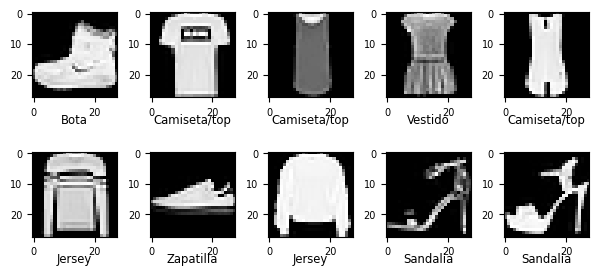

In [5]:
import matplotlib.pyplot as plt

# primero, vemos unas imagenes del set de entrenamiento con sus etiquetas (labels)
figure = plt.figure(figsize=(6, 3)) # Adjusted figure size for 2 rows of 5 images

# configurar tamaño de texto para las graficas
plt.rc('font', size=7)

for i in range(0,10):
  figure.add_subplot(2, 5, i+1) # Changed to 2 rows, 5 columns
  img, label = dataset_train[i]

  # img tiene dimensiones [1,28,28], squeeze() destruye las dimensiones de tamaño 1
  plt.imshow(img.squeeze(), cmap='Greys_r')
  #plt.axis('off')
  plt.title(desc[label], y=-0.4)
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show() # Display the plot

In [6]:
import torch.nn as nn

# Tamaño de entrada, en este caso el tamaño
# de las imagenes de entrada: 28*28 = 784
input_size = 784 # @param {type:"integer"}

# Tamaño de salida (número de clases en un problema de clasificación)
# en este caso hay 10 clases (números del 0 al 9)
output_size = len(desc)

# Definir la arquitectura de la red MLP
class MLP(nn.Module):

    def __init__(self, hidden_size, activation_function_option):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) # capa fully connected

        # Almacenamos la función de activación seleccionada
        if activation_function_option == "ReLU":
            self.activation = nn.ReLU()
        elif activation_function_option == "Sigmoid":
            self.activation = nn.Sigmoid()
        elif activation_function_option == "Tanh":
            self.activation = nn.Tanh()
        else:
            raise ValueError("Función de activación no soportada")

        self.fc2 = nn.Linear(hidden_size, output_size) # capa fully connected
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x) # Usamos la función de activación almacenada
        x = self.fc2(x)
        x = self.softmax(x)
        return x


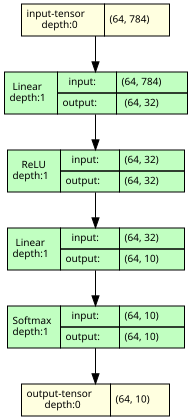

In [7]:
# diagrama con la arquitectura de red
# Definir los parámetros necesarios para el constructor de MLP
hidden_size = 32 # Usando el valor anterior como ejemplo
activation_function_option = "ReLU" # Usando el valor predeterminado como ejemplo

model = MLP(hidden_size, activation_function_option)
model_graph = draw_graph(model, input_size=(batch_size, input_size))
model_graph.visual_graph

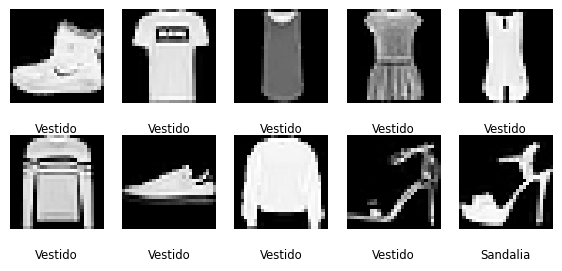

In [8]:
# Como se comporta la red neuronal antes de entrenar?

# primero, inicializamos el generador de numeros aleatorios
# con una semilla, para obtener resultados deterministas
torch.manual_seed(42)

# Creamos una instancia del modelo con los parámetros actuales
model = MLP(hidden_size, activation_function_option)
model.to(device)

# generamos un grafico para representar las imagenes
figure = plt.figure(figsize=(7, 3))

for i in range(0,10):

  # calculamos la salida del modelo con los parametros iniciales aleatorios
  input = dataset_train.data[i].view(1, 28*28).float().to(device)
  output = model(input)

  # de las diez neuronas de salida, la que tenga
  # mayor valor corresponde a la prediccion del modelo
  pred = output.argmax(dim=1, keepdim=True)


  # graficamos el resultado
  figure.add_subplot(2, 5, i+1)
  plt.axis('off')
  plt.imshow(dataset_train.data[i], cmap='Greys_r')
  plt.title(desc[pred.item()], y=-0.4)

In [9]:
# funcion de entrenamiento
def train(model, optimizer, loss_training_list):

    # configurar el modelo en modo entrenamiento
    # se necesita para que capas como batchnorm o dropout se comporten correctamente
    model.train()

    # iteramos por los mini-batches del set de entrenamiento
    for batch_idx, (data, target) in enumerate(train_loader):

        # mandamos los datos al dispositivo (necesario cuando se usa la GPU)
        data, target = data.to(device), target.to(device)

        # se resetean a cero los gradientes antes de cada paso de optimización
        optimizer.zero_grad()

        # calculamos la salida del modelo (prediccion)
        output = model(data.view(data.shape[0], 28*28)) # la entrada es un tensor [batch_size, 28*28]

        # definimos la funcion de perdida como el error cuadratico medio
        # como la prediccion del modelo es un vector de 10 elementos (las 10 neuronales finales)
        # hay que convertir la label del set de entrenamiento en un vector
        # con el valor correspondiente 1 y todos los demas valores 0 (un vector one-hot)
        target_onehot = F.one_hot(target, num_classes=10).float()
        loss = F.mse_loss(output, target_onehot)

        # se ejecuta el backpropagation para calcular el gradiente
        loss.backward()

        # se actualizan los pesos y sesgos de la red
        optimizer.step()

        # se guarda el historico de la perdida para graficarlo
        loss_training_list.append(loss.item())

        # cada 50 mini-batches, imprimimos por pantalla la perdida
        print_interval = 50
        if batch_idx % print_interval == 0:
            print('   Loss: ', loss.item())

    print('Training Epoch completa\n')


In [10]:
# funcion de test
def test(model, split, loss_history_list):

    # podemos ejecutar el test sobre el split de test o el training
    # asi vemos despues si tenemos overfitting
    if split == 'train':
        loader = train_loader
    else:
        loader = test_loader

    # lista para almacenar los fallos, ahora local para la ejecución del test
    errorList_local = []
    correct = 0
    test_loss = 0

    # configurar el modelo en modo evaluacion o inferencia
    # se necesita para que capas como batchnorm o dropout se comporten correctamente
    model.eval()

    # durante el test solo hacemos el forward pass y no necesitamos los gradientes
    with torch.no_grad():
        for data, target in loader:

            # mandamos los datos al dispositivo (necesario cuando se usa la GPU)
            data, target = data.to(device), target.to(device)

            # calculamos la salida del modelo (prediccion)
            output = model(data.view(data.shape[0], 28*28))
            target_onehot = F.one_hot(target, num_classes=10).float()

            # suma acumulada de la perdida
            test_loss += F.mse_loss(output, target_onehot, reduction='sum')

            # de las diez neuronas de salida, la que tenga
            # mayor valor corresponde a la prediccion del modelo
            pred = output.argmax(dim=1, keepdim=True)

            # si la prediccion es igual al valor etiquetado, se cuenta como correcto
            correct += pred.eq(target.view_as(pred)).sum().item()

            # los que no sean iguales al valor etiquetado,
            # se meten en un array de errores
            for index, error in enumerate(pred.ne(target.view_as(pred))):
              if (error):
                errorList_local.append({
                    "data": data[index],
                    "pred": pred[index],
                    "target": target[index]
                    })

    # se divide el acumulado de la perdida por el tamaño del dataset
    # para obtener la media de la perdida
    # se divide tambien por 10, que es el tamaño del one-hot vector (el numero de clases)
    test_loss /= len(loader.dataset)*10

    # se guarda el historico de la perdida en la lista proporcionada
    loss_history_list.append(test_loss.item())

    accuracy = 100 * correct / len(loader.dataset)

    # imprimir por pantalla los resultados del test
    print(f'Test (split {split}):\n   Loss medio: {test_loss.item():.4f} Errores: {len(errorList_local)} Precision: {accuracy:.2f}%\n')

    return test_loss.item(), accuracy, len(errorList_local) # Retornar las métricas


In [11]:
# ejecutamos un test antes de empezar el entrenamiento
# la precision debe ser sobre el 10% (como hay 10 etiquetas,
# 1 de cada 10 el modelo acertara)
model = MLP(hidden_size, activation_function_option)
model.to(device)
loss_test_split = []
test(model, 'test', loss_test_split)

Test (split test):
   Loss medio: 0.0911 Errores: 9197 Precision: 8.03%



(0.0911479964852333, 8.03, 9197)

In [12]:
# entrenamos la red

# semilla del generador de numeros aleatorios
# para conseguir resultados deterministas
torch.manual_seed(42)

# lista para graficar la perdida de entrenamiento y test
loss_training = []
loss_test_split = []
loss_train_split = []

# Crear una instancia del modelo y pasarla al dispositivo
# Usamos los valores definidos globalmente (o localmente para cada experimento)
model = MLP(hidden_size, activation_function_option)
model.to(device)

# optimizador, mini-batch gradient descent
# (en pytorch le llaman stochastic gradient descent, pero es un mini-batch gradient descent)
optimizer = optim.SGD(model.parameters(), lr=1.0)

# learning rate decay, se multiplica por gamma cada step_size steps
scheduler = StepLR(optimizer, step_size=1, gamma=0.7)

epochs = 10
for epoch in range(0, epochs):
    print('Epoch:', epoch, 'LR:', scheduler.get_last_lr())
    train(model, optimizer, loss_training)
    test(model, 'test', loss_test_split)
    test(model, 'train', loss_train_split)
    scheduler.step()


Epoch: 0 LR: [1.0]
   Loss:  0.09180931746959686
   Loss:  0.045035697519779205
   Loss:  0.03851945325732231
   Loss:  0.04060601443052292
   Loss:  0.024797264486551285
   Loss:  0.03425910323858261
   Loss:  0.03564893454313278
   Loss:  0.01525256596505642
   Loss:  0.035454291850328445
   Loss:  0.02597338892519474
   Loss:  0.02940000221133232
   Loss:  0.017405707389116287
   Loss:  0.02556879259645939
   Loss:  0.03168685361742973
   Loss:  0.028727728873491287
   Loss:  0.022899877279996872
   Loss:  0.03147171437740326
   Loss:  0.02503472939133644
   Loss:  0.02308276854455471
Training Epoch completa

Test (split test):
   Loss medio: 0.0248 Errores: 1715 Precision: 82.85%

Test (split train):
   Loss medio: 0.0228 Errores: 9315 Precision: 84.47%

Epoch: 1 LR: [0.7]
   Loss:  0.018839437514543533
   Loss:  0.028026219457387924
   Loss:  0.024732958525419235
   Loss:  0.027110863476991653
   Loss:  0.018959615379571915
   Loss:  0.024612415581941605
   Loss:  0.02741173841059

In [ ]:
# Definir las combinaciones de parámetros a probar
configurations = [
    {"hidden_size": 72, "activation_function_option": "ReLU"}
]

results = []
epochs = 10

for config in configurations:
    print(f"\nEntrenando con hidden_size={config['hidden_size']} y activation_function_option={config['activation_function_option']}")

    # Restablecer la semilla para reproducibilidad en cada experimento
    torch.manual_seed(42)

    # Crear el modelo con los parámetros de la configuración actual
    model = MLP(config['hidden_size'], config['activation_function_option'])
    model.to(device)

    # Inicializar optimizador y scheduler para el modelo actual
    optimizer = optim.SGD(model.parameters(), lr=1.0)
    scheduler = StepLR(optimizer, step_size=1, gamma=0.7)

    # Listas para almacenar las pérdidas de este experimento
    loss_training_current = []
    loss_test_split_current = []
    loss_train_split_current = []

    for epoch in range(0, epochs):
        print(f'Epoch: {epoch} LR: {scheduler.get_last_lr()}')
        train(model, optimizer, loss_training_current)
        test(model, 'test', loss_test_split_current)
        test(model, 'train', loss_train_split_current)
        scheduler.step()

    # Almacenar los resultados finales (p.ej., la última precisión en test)
    final_test_loss, final_test_accuracy, _ = test(model, 'test', loss_test_split_current)
    results.append({
        "hidden_size": config['hidden_size'],
        "activation_function_option": config['activation_function_option'],
        "final_test_accuracy": final_test_accuracy,
        "final_test_loss": final_test_loss
    })

# Imprimir un resumen de todos los resultados
print("\n--- Resumen de Resultados ---")
for res in results:
    print(f"Hidden Size: {res['hidden_size']}, Activación: {res['activation_function_option']}, Precisión Final en Test: {res['final_test_accuracy']:.2f}%, Pérdida Final en Test: {res['final_test_loss']:.4f}")

# Opcional: Graficar la evolución de la pérdida para cada configuración
# Esto requeriría almacenar más datos o iterar sobre 'results' y cargar las pérdidas almacenadas


Entrenando con hidden_size=72 y activation_function_option=ReLU
Epoch: 0 LR: [1.0]
   Loss:  0.08929836750030518
   Loss:  0.0461798794567585
   Loss:  0.0363788977265358
   Loss:  0.03855763003230095
   Loss:  0.024168599396944046
   Loss:  0.03348923847079277
   Loss:  0.032724086195230484
   Loss:  0.014560121111571789
   Loss:  0.03324570134282112
   Loss:  0.025774050503969193
   Loss:  0.0295479204505682
   Loss:  0.01787360943853855
   Loss:  0.025314023718237877
   Loss:  0.03254595026373863
   Loss:  0.02761112153530121
   Loss:  0.022271951660513878
   Loss:  0.02986193634569645
   Loss:  0.024806715548038483
   Loss:  0.02213439904153347
Training Epoch completa

Test (split test):
   Loss medio: 0.0245 Errores: 1704 Precision: 82.96%

Test (split train):
   Loss medio: 0.0225 Errores: 9319 Precision: 84.47%

Epoch: 1 LR: [0.7]
   Loss:  0.017260942608118057
   Loss:  0.02704632841050625
   Loss:  0.021485159173607826
   Loss:  0.027965132147073746
   Loss:  0.01663797721266

In [ ]:
# graficamos la perdida durante el entrenamiento
plt.plot(loss_training)

In [ ]:
# pintamos algunas predicciones
figure = plt.figure(figsize=(8, 8))

for i in range(0,15):

  # calcula la salida del modelo con los parametros entrenados
  # Se cambia .resize() por .reshape() para evitar la advertencia de deprecación.
  input = dataset_train.data[i].reshape(1, 28*28).float().to(device)

  # Get the actual target label before passing to model
  _, target_label = dataset_train[i]

  output = model(input)

  # de las diez neuronas de salida, la que tenga
  # mayor valor corresponde a la prediccion del modelo
  pred = output.argmax(dim=1, keepdim=True)

  # pintamos la imagen y la prediccion del modelo
  figure.add_subplot(3, 5, i+1)
  plt.axis('off')
  plt.imshow(dataset_train.data[i], cmap='Greys_r')
  plt.title(f"Pred: {desc[pred.item()]}\nReal: {desc[target_label]}", y=-0.6)